# Random Forest Regression – Combined Dataset Training

**Goal:** Combine both datasets (1200 + 100 = 1300 rows), impute missing
values, and train a Random Forest that knows both clean patterns and edge cases.

**Workflow:**
1. Load and combine both datasets
2. Impute missing values (median or mode, depending on column type)
3. Train/test split on the combined data
4. Train Random Forest and evaluate
5. Also test specifically on stress-test rows
6. Compare with previous results


## Step 1 – Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

print("All imports successful.")


All imports successful.


## Step 2 – Load and Combine Both Datasets

In [2]:
df_main   = pd.read_csv("meat_price_dataset.csv")
df_stress = pd.read_csv("meat_price_100_stress_test.csv")

# Add a source column so we can identify rows later
df_main["source"]   = "main"
df_stress["source"] = "stress"

df_combined = pd.concat([df_main, df_stress], ignore_index=True)

print(f"Main dataset:     {len(df_main)} rows")
print(f"Stress dataset:   {len(df_stress)} rows")
print(f"Combined dataset: {len(df_combined)} rows")
print(f"Missing values:{df_combined.isnull().sum()}")


Main dataset:     1200 rows
Stress dataset:   100 rows
Combined dataset: 1300 rows
Missing values:meat_type             9
fat_content_pct      14
protein_pct          10
marbling_score       11
animal_age_months     8
storage_days          9
organic               9
cut_quality           7
price_eur_per_kg      9
source                0
dtype: int64


## Step 3 – Impute Missing Values: Median vs Mode

**Why not one method for all columns?**

Each column has a different data type, and the right fill depends on that type:

| Column | Type | Fill Method | Why |
|---|---|---|---|
| `meat_type` | Categorical (1–5) | **Mode** | It represents a category (beef, pork, etc.). The average of "beef" and "chicken" makes no sense. Mode = most common category. |
| `fat_content_pct` | Continuous float | **Median** | A real number with a distribution. Median is robust against outliers — if most values are 15–25% but one is 90%, the median ignores the outlier while the mean gets pulled up. |
| `protein_pct` | Continuous float | **Median** | Same reason — continuous measurement, median is robust. |
| `marbling_score` | Ordinal integer (1–10) | **Median** | Ordered scale. Median respects the ordering ("middle grade") while mode just picks the most frequent, which could be an extreme. |
| `animal_age_months` | Continuous integer | **Median** | Age in months is continuous. Median is more representative than mode for age data. |
| `storage_days` | Continuous integer | **Median** | Days in storage is continuous. Same reasoning. |
| `organic` | Binary (0 or 1) | **Mode** | Only two values — median of 0s and 1s could give 0.5, which is meaningless. Mode picks the more common category. |
| `cut_quality` | Ordinal integer (1–5) | **Median** | Ordered quality scale. Median = "middle quality" is a reasonable fill. |
| `price_eur_per_kg` | Continuous float | **Median** | Our target variable. Median price is a safer fill than mean when outliers exist. |

**Rule of thumb:**
- **Categorical / Binary** → Mode (most frequent value)
- **Continuous / Ordinal** → Median (middle value, robust against outliers)


In [3]:
# Define which columns get which strategy
mode_cols   = ["meat_type", "organic"]
median_cols = ["fat_content_pct", "protein_pct", "marbling_score",
               "animal_age_months", "storage_days", "cut_quality",
               "price_eur_per_kg"]

print("=== Imputation Plan ===")
print(f"Mode (most frequent):  {mode_cols}")
print(f"Median (middle value): {median_cols}")

# Show values before imputation
print("=== Fill Values ===")
for col in mode_cols:
    fill_val = df_combined[col].mode()[0]
    n_missing = df_combined[col].isnull().sum()
    print(f"{col:<20} Mode = {fill_val:<8} ({n_missing} NaN to fill)")

for col in median_cols:
    fill_val = df_combined[col].median()
    n_missing = df_combined[col].isnull().sum()
    print(f"{col:<20} Median = {fill_val:<8.2f} ({n_missing} NaN to fill)")


=== Imputation Plan ===
Mode (most frequent):  ['meat_type', 'organic']
Median (middle value): ['fat_content_pct', 'protein_pct', 'marbling_score', 'animal_age_months', 'storage_days', 'cut_quality', 'price_eur_per_kg']
=== Fill Values ===
meat_type            Mode = 3.0      (9 NaN to fill)
organic              Mode = 0.0      (9 NaN to fill)
fat_content_pct      Median = 18.35    (14 NaN to fill)
protein_pct          Median = 20.40    (10 NaN to fill)
marbling_score       Median = 5.00     (11 NaN to fill)
animal_age_months    Median = 36.00    (8 NaN to fill)
storage_days         Median = 10.00    (9 NaN to fill)
cut_quality          Median = 3.00     (7 NaN to fill)
price_eur_per_kg     Median = 23.71    (9 NaN to fill)


In [4]:
# Apply imputation
for col in mode_cols:
    df_combined[col] = df_combined[col].fillna(df_combined[col].mode()[0])

for col in median_cols:
    df_combined[col] = df_combined[col].fillna(df_combined[col].median())

print("Missing values after imputation:")
print(df_combined.isnull().sum())
print(f"Total rows: {len(df_combined)}")


Missing values after imputation:
meat_type            0
fat_content_pct      0
protein_pct          0
marbling_score       0
animal_age_months    0
storage_days         0
organic              0
cut_quality          0
price_eur_per_kg     0
source               0
dtype: int64
Total rows: 1300


## Step 4 – Define Features and Target


In [5]:
target_col = "price_eur_per_kg"
feature_cols = [c for c in df_combined.columns if c not in [target_col, "source"]]

print("Features:", feature_cols)

X = df_combined[feature_cols]
y = df_combined[target_col]

print(f"X shape: {X.shape}  |  y shape: {y.shape}")


Features: ['meat_type', 'fat_content_pct', 'protein_pct', 'marbling_score', 'animal_age_months', 'storage_days', 'organic', 'cut_quality']
X shape: (1300, 8)  |  y shape: (1300,)


## Step 5 – Train / Test Split (80/20)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
)

# Check how many stress rows ended up in train vs test
source_col = df_combined["source"]
train_idx = X_train.index
test_idx  = X_test.index

print(f"Train set: {len(X_train)} rows ({source_col.loc[train_idx].value_counts().to_dict()})")
print(f"Test  set: {len(X_test)} rows ({source_col.loc[test_idx].value_counts().to_dict()})")


Train set: 1040 rows ({'main': 961, 'stress': 79})
Test  set: 260 rows ({'main': 239, 'stress': 21})


## Step 6 – Train the Random Forest


In [7]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=7,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

print("Model trained.")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Max depth:       {rf_model.max_depth}")


Model trained.
Number of trees: 200
Max depth:       7


## Step 7 – Evaluate on the Full Test Set (mixed main + stress rows)


In [8]:
y_pred = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== Full Test Set ===")
print(f"MAE:  {mae:.2f} EUR")
print(f"RMSE: {rmse:.2f} EUR")
print(f"R²:   {r2:.4f}")
print(f"Relative error: {mae / y_test.mean() * 100:.1f}%")


=== Full Test Set ===
MAE:  2.68 EUR
RMSE: 4.37 EUR
R²:   0.7475
Relative error: 11.4%


## Step 8 – Evaluate Separately: Main vs Stress Rows in Test Set

We split the test set by source to see how the model performs on
each type of data individually.


In [9]:
# Split test set by source
test_source = source_col.loc[test_idx]

main_mask   = test_source == "main"
stress_mask = test_source == "stress"

if main_mask.sum() > 0:
    y_test_main = y_test[main_mask]
    y_pred_main = y_pred[main_mask.values]
    print(f"=== Main-Data Rows in Test ({main_mask.sum()} rows) ===")
    print(f"MAE:  {mean_absolute_error(y_test_main, y_pred_main):.2f} EUR")
    print(f"R²:   {r2_score(y_test_main, y_pred_main):.4f}")

if stress_mask.sum() > 0:
    y_test_stress = y_test[stress_mask]
    y_pred_stress = y_pred[stress_mask.values]
    print(f"=== Stress-Data Rows in Test ({stress_mask.sum()} rows) ===")
    print(f"MAE:  {mean_absolute_error(y_test_stress, y_pred_stress):.2f} EUR")
    print(f"R²:   {r2_score(y_test_stress, y_pred_stress):.4f}")
else:
    print("No stress-test rows in this test split.")


=== Main-Data Rows in Test (239 rows) ===
MAE:  2.15 EUR
R²:   0.8841
=== Stress-Data Rows in Test (21 rows) ===
MAE:  8.70 EUR
R²:   -0.3082


## Step 9 – Actual vs Predicted Plots


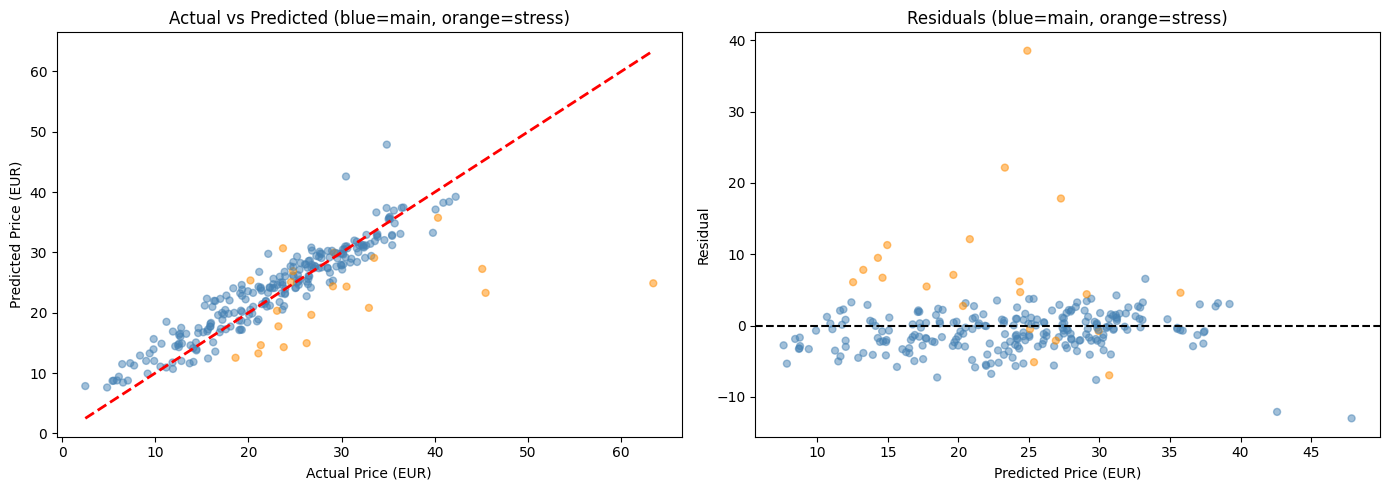

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color-coded by source
test_colors = ["steelblue" if s == "main" else "darkorange" for s in test_source]

axes[0].scatter(y_test, y_pred, alpha=0.5, s=25, c=test_colors)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Actual Price (EUR)")
axes[0].set_ylabel("Predicted Price (EUR)")
axes[0].set_title("Actual vs Predicted (blue=main, orange=stress)")

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, s=25, c=test_colors)
axes[1].axhline(y=0, color="black", linestyle="--")
axes[1].set_xlabel("Predicted Price (EUR)")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals (blue=main, orange=stress)")

plt.tight_layout()
plt.show()


## Step 10 – Feature Importance


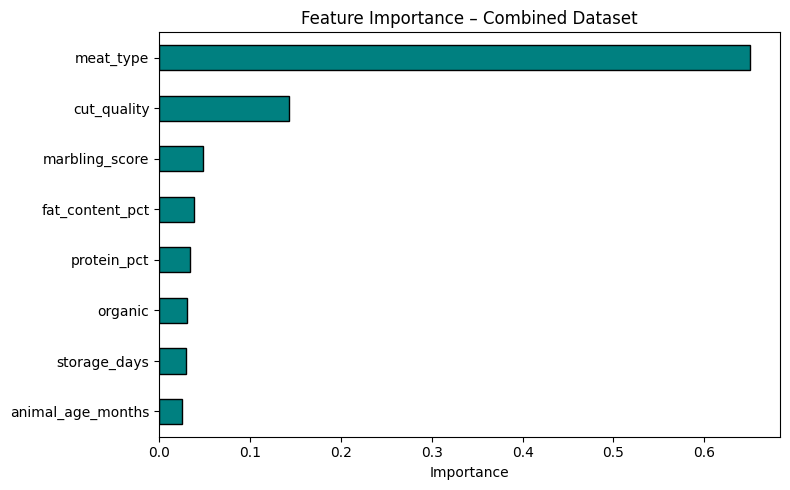

Importance values:
animal_age_months    0.0249
storage_days         0.0293
organic              0.0308
protein_pct          0.0343
fat_content_pct      0.0388
marbling_score       0.0485
cut_quality          0.1426
meat_type            0.6508
dtype: float64


In [11]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="teal", edgecolor="black")
ax.set_title("Feature Importance – Combined Dataset")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Importance values:")
print(importances.round(4))


## Step 11 – Full Comparison with Previous Experiments


In [12]:
print("=" * 75)
print("COMPARISON: All Experiments")
print("=" * 75)

comparison = pd.DataFrame({
    "Experiment": [
        "DT baseline (depth 7)",
        "DT GridSearchCV",
        "RF baseline (separate datasets)",
        "RF GridSearch (separate datasets)",
        "RF + KNN imputation",
        "RF combined dataset (this notebook)",
    ],
    "R² Test": [
        "0.8737",
        "0.8875",
        "0.9249",
        "0.9215",
        "0.9249",
        f"{r2:.4f}",
    ],
    "R² Stress": [
        "-0.2544",
        "-0.3108",
        "-0.3288",
        "-0.2711",
        "-0.2806",
        "(see Step 8)",
    ],
})

print(comparison.to_string(index=False))
print("--- Done! ---")


COMPARISON: All Experiments
                         Experiment R² Test    R² Stress
              DT baseline (depth 7)  0.8737      -0.2544
                    DT GridSearchCV  0.8875      -0.3108
    RF baseline (separate datasets)  0.9249      -0.3288
  RF GridSearch (separate datasets)  0.9215      -0.2711
                RF + KNN imputation  0.9249      -0.2806
RF combined dataset (this notebook)  0.7475 (see Step 8)
--- Done! ---
